# Polygon conservative regridder — basics

`ConservativeRegridder` is a polygon-intersection conservative regridder that complements
the existing `.conservative` method. Where `.conservative` uses fast axis-factored 1D overlap
(rectilinear grids only), this path computes explicit 2D cell-polygon intersections — handling
curvilinear and unstructured meshes and supporting a spherical-area mode for global lat/lon
grids, at the cost of slightly higher build time.

This notebook shows the basic workflow on an analytic field with a known sphere integral.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import xarray_regrid  # registers the `.regrid` accessor
from xarray_regrid import ConservativeRegridder

np.set_printoptions(precision=5, suppress=True)

## Synthetic source field

We use $f(\lambda, \phi) = \cos^2(\phi)$ on a 1° global grid. Its true integral over the unit
sphere is $8\pi/3$, which gives us a check on the regridder.

In [2]:
lat = np.linspace(-89.5, 89.5, 180)
lon = np.linspace(-179.5, 179.5, 360)
field = (np.cos(np.deg2rad(lat))**2)[:, None] * np.ones(lon.size)[None, :]
src = xr.DataArray(
    field,
    dims=("latitude", "longitude"),
    coords={"latitude": lat, "longitude": lon},
    name="cos2_lat",
)
src

<xarray.DataArray 'cos2_lat' (latitude: 180, longitude: 360)> Size: 518kB
array([[0.00008, 0.00008, 0.00008, ..., 0.00008, 0.00008, 0.00008],
       [0.00069, 0.00069, 0.00069, ..., 0.00069, 0.00069, 0.00069],
       [0.0019 , 0.0019 , 0.0019 , ..., 0.0019 , 0.0019 , 0.0019 ],
       ...,
       [0.0019 , 0.0019 , 0.0019 , ..., 0.0019 , 0.0019 , 0.0019 ],
       [0.00069, 0.00069, 0.00069, ..., 0.00069, 0.00069, 0.00069],
       [0.00008, 0.00008, 0.00008, ..., 0.00008, 0.00008, 0.00008]],
      shape=(180, 360))
Coordinates:
  * latitude   (latitude) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5

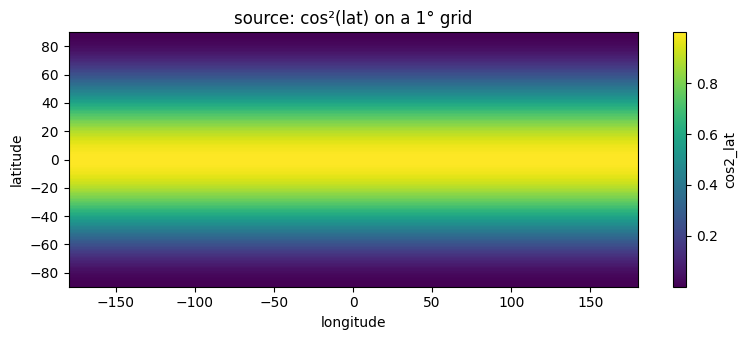

In [3]:
src.plot(figsize=(8, 3.5), cmap="viridis")
plt.title("source: cos²(lat) on a 1° grid")
plt.tight_layout()

## Target grid

A coarser 3° grid. We'll build an empty `xr.Dataset` with just the target coords;
`xarray-regrid` identifies the grid from `latitude` and `longitude`.

In [4]:
target = xr.Dataset(coords={
    "latitude": np.linspace(-88.5, 88.5, 60),
    "longitude": np.linspace(-178.5, 178.5, 120),
})

## Regrid via the `.regrid.conservative_polygon` accessor

`spherical=True` applies an analytic Lambert cylindrical equal-area projection
to the cell edges before intersecting — correct spherical area weights at the
same cost as the planar fast path. Leave it off when your coords aren't geographic degrees.

In [5]:
regridded = src.regrid.conservative_polygon(
    target, x_coord="longitude", y_coord="latitude", spherical=True
)
regridded

<xarray.DataArray 'cos2_lat' (latitude: 60, longitude: 120)> Size: 58kB
array([[0.00129, 0.00129, 0.00129, ..., 0.00129, 0.00129, 0.00129],
       [0.00676, 0.00676, 0.00676, ..., 0.00676, 0.00676, 0.00676],
       [0.01763, 0.01763, 0.01763, ..., 0.01763, 0.01763, 0.01763],
       ...,
       [0.01763, 0.01763, 0.01763, ..., 0.01763, 0.01763, 0.01763],
       [0.00676, 0.00676, 0.00676, ..., 0.00676, 0.00676, 0.00676],
       [0.00129, 0.00129, 0.00129, ..., 0.00129, 0.00129, 0.00129]],
      shape=(60, 120))
Coordinates:
  * latitude   (latitude) float64 480B -88.5 -85.5 -82.5 ... 82.5 85.5 88.5
  * longitude  (longitude) float64 960B -178.5 -175.5 -172.5 ... 175.5 178.5

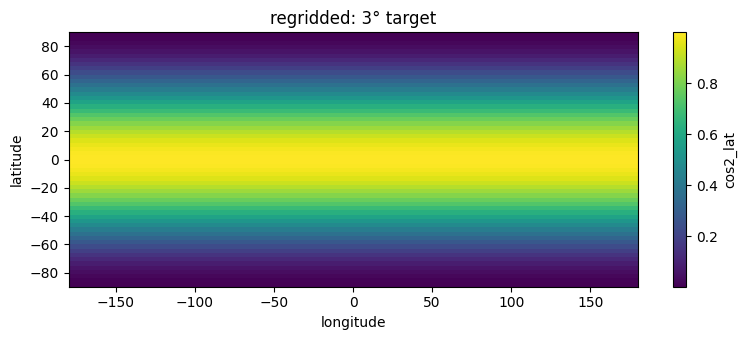

In [6]:
regridded.plot(figsize=(8, 3.5), cmap="viridis")
plt.title("regridded: 3° target")
plt.tight_layout()

## Mass-conservation diagnostic

A correct conservative regrid preserves the area-weighted integral (on the sphere).
We compute true spherical cell areas for each grid and compare the integrals.

In [7]:
def sph_integral(da):
    lat_r = np.deg2rad(da.latitude.values)
    dlat = np.gradient(lat_r)
    dlon = np.gradient(np.deg2rad(da.longitude.values))
    area = (np.sin(lat_r + dlat/2) - np.sin(lat_r - dlat/2))[:, None] * dlon[None, :]
    return float((da.values * area).sum())

true_val = 8 * np.pi / 3
src_sum = sph_integral(src)
out_sum = sph_integral(regridded)
print(f"true sphere integral : {true_val:.6f}")
print(f"source integral      : {src_sum:.6f}  (err {src_sum - true_val:+.2e})")
print(f"regridded integral   : {out_sum:.6f}  (err {out_sum - true_val:+.2e})")

true sphere integral : 8.377580
source integral      : 8.377474  (err -1.06e-04)
regridded integral   : 8.377474  (err -1.06e-04)


## Spherical vs planar vs the axis-factored path

`spherical=False` uses raw lat/lon planar geometry — poor near the poles.
The existing `.conservative` method applies an analytic sin-weighting to the factored
1D overlap. On lat/lon grids, `spherical=True` reproduces that accuracy while also
working on curvilinear and unstructured targets the factored path can't express.

In [8]:
def err(fn):
    return abs(sph_integral(fn()) - true_val)

results = {
    "polygon, spherical=True ": err(lambda: src.regrid.conservative_polygon(
        target, x_coord="longitude", y_coord="latitude", spherical=True)),
    "polygon, spherical=False": err(lambda: src.regrid.conservative_polygon(
        target, x_coord="longitude", y_coord="latitude", spherical=False)),
    "factored (.conservative)": err(lambda: src.regrid.conservative(
        target, latitude_coord="latitude")),
}
for k, v in results.items():
    print(f"{k}:  |error| = {v:.2e}")

polygon, spherical=True :  |error| = 1.06e-04
polygon, spherical=False:  |error| = 1.81e-03
factored (.conservative):  |error| = 1.06e-04
